# Building a simple workflow and langgraph

In [1]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_info:str

### Node defination

In [2]:
def start_play(state:State):
    print("state_play node has be executed")
    return {"graph_info": state["graph_info"] + " I am starting to play"}


def cricket_node(state:State):
    print("Cricket node has be executed")
    return {"graph_info": state["graph_info"] + " Cricket"}

def football_node(state:State):
    print("Football node has be executed")
    return {"graph_info": state["graph_info"] + " Football"}

### Condition Defination

In [3]:
import random
from typing import Literal

def random_play(state:State) -> Literal["cricket_node", "football_node"]:
    graph_info = state["graph_info"]

    if random.random() > 0.5:
        return "football_node"
    else:
        return "cricket_node"

### Creating Edges

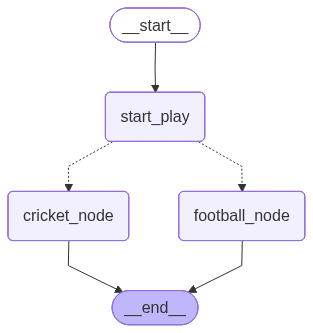

In [4]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# graph variable
graph = StateGraph(State)


# Creating nodes
graph.add_node("start_play", start_play)
graph.add_node("cricket_node", cricket_node)
graph.add_node("football_node", football_node)


# Creating edges
graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("cricket_node", END)
graph.add_edge("football_node", END)


# Creating graph
graph_builder = graph.compile()


# View the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

## Graph Invokation

In [8]:
graph_builder.invoke({
    "graph_info": "Hi My name is Abhishek Biswas."
})

state_play node has be executed
Football node has be executed


{'graph_info': 'Hi My name is Abhishek Biswas. I am starting to play Football'}